In [1]:
# === GLOBAL IMPORTS & SEED FIXING ===
import os
import gc
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Fix random seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

# Sklearn
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.utils import shuffle

# Keras (modern TF imports only)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
)
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)
print("Seed fixed:", SEED)

2026-05-17 19:02:53.270952: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779044573.464276      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779044573.520155      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779044574.003044      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779044574.003096      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779044574.003099      22 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: True
Seed fixed: 42



## Helper Functions

In [2]:
# === HELPER: Compute specificity from confusion matrix ===
def compute_specificity(cm):
    """Compute mean specificity across all classes from a confusion matrix."""
    spec_list = []
    for i in range(len(cm)):
        TP = cm[i, i]
        FN = np.sum(cm[i, :]) - TP
        FP = np.sum(cm[:, i]) - TP
        TN = np.sum(cm) - (TP + FN + FP)
        denom = TN + FP
        spec = TN / denom if denom > 0 else 0.0
        spec_list.append(spec)
    return float(np.mean(spec_list))


# === HELPER: Print metrics table ===
def print_metrics(split_name, accuracy, f1, sensitivity, specificity):
    print(f"\n{'='*50}")
    print(f" {split_name} METRICS")
    print(f"{'='*50}")
    print(f"  Accuracy    : {accuracy:.4f}  ({accuracy*100:.2f}%)")
    print(f"  F1-Score    : {f1:.4f}")
    print(f"  Sensitivity : {sensitivity:.4f}")
    print(f"  Specificity : {specificity:.4f}")
    print(f"{'='*50}")


# === HELPER: Compute all binary/multiclass metrics ===
def compute_metrics(y_true, y_pred, average='weighted'):
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average=average, zero_division=0)
    sens = recall_score(y_true, y_pred, average=average, zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)
    spec = compute_specificity(cm)
    return acc, f1, sens, spec, cm


# === HELPER: Plot confusion matrix ===
def plot_confusion_matrix(cm, class_names, title='Confusion Matrix', figsize=(6,5)):
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        linewidths=0.5, ax=ax
    )
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [3]:
# === DATASET PATHS ===
CHEST_BASE = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/'
CHEST_TRAIN_DIR = CHEST_BASE + 'train/'
CHEST_TEST_DIR  = CHEST_BASE + 'test/'
CHEST_VAL_DIR   = CHEST_BASE + 'val/'

CLASSES = {'NORMAL': 0, 'PNEUMONIA': 1}
CLASS_NAMES = ['NORMAL', 'PNEUMONIA']
IMG_SIZE_SVM = 200   # for SVM (grayscale)
IMG_SIZE_CNN = 224   # for CNN (RGB)

# === LOAD DATA FOR SVM (grayscale, flattened) ===
def load_svm_data(base_dir, classes, img_size=200):
    """Load grayscale images, resize, flatten, and normalize for SVM.""" 
    X, y = [], []
    for cls, label in classes.items():
        folder = os.path.join(base_dir, cls)
        for fname in sorted(os.listdir(folder)):
            fpath = os.path.join(folder, fname)
            img = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))
            X.append(img.flatten() / 255.0)
            y.append(label)
    return np.array(X), np.array(y)


print("Loading SVM training data (grayscale) from train/ ...")
X_train_flat, y_train = load_svm_data(CHEST_TRAIN_DIR, CLASSES, IMG_SIZE_SVM)
print(f"  Train shape: {X_train_flat.shape}, Labels: {np.bincount(y_train)}")

print("\nLoading SVM test data (grayscale) from test/ ...")
X_test_flat, y_test = load_svm_data(CHEST_TEST_DIR, CLASSES, IMG_SIZE_SVM)
print(f"  Test shape : {X_test_flat.shape}, Labels: {np.bincount(y_test)}")

Loading SVM training data (grayscale) from train/ ...
  Train shape: (5216, 40000), Labels: [1341 3875]

Loading SVM test data (grayscale) from test/ ...
  Test shape : (624, 40000), Labels: [234 390]


In [4]:
# ==============================================================
# APPLY PCA FOR SVM
# ==============================================================

print("\nApplying PCA on SVM training data...")

pca = PCA(n_components=0.98, random_state=SEED)
pca_train = pca.fit_transform(X_train_flat)
pca_test = pca.transform(X_test_flat)
print(f"Original feature size : {X_train_flat.shape[1]}")
print(f"PCA components kept   : {pca.n_components_}")
print(f"Variance retained     : "f"{sum(pca.explained_variance_ratio_) * 100:.2f}%")
print(f"PCA train shape       : {pca_train.shape}")
print(f"PCA test shape        : {pca_test.shape}")


Applying PCA on SVM training data...
Original feature size : 40000
PCA components kept   : 1723
Variance retained     : 98.00%
PCA train shape       : (5216, 1723)
PCA test shape        : (624, 1723)


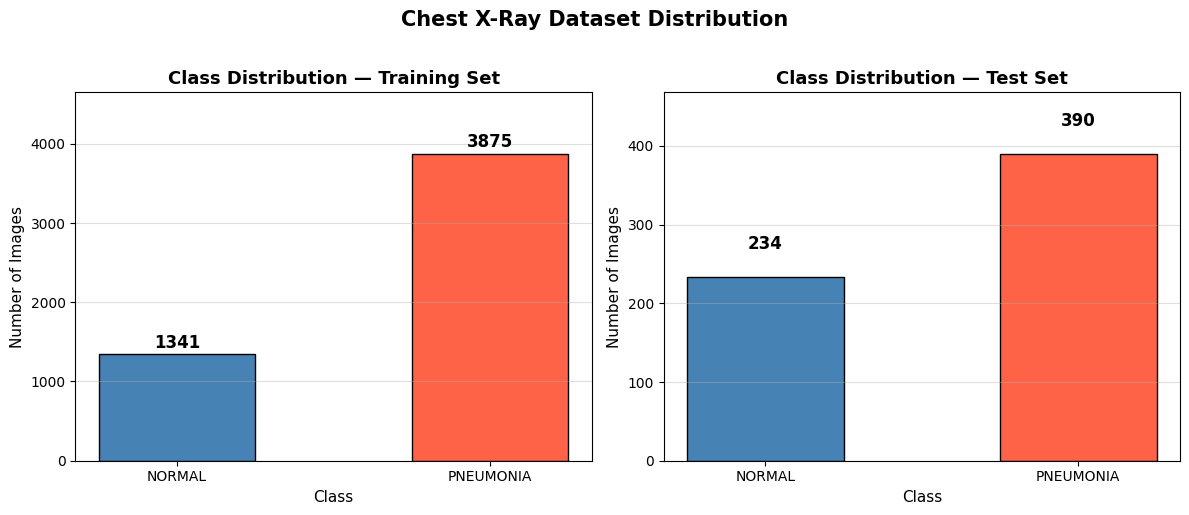


Training set total: 5216 images
Test set total    : 624 images


In [5]:
# === DATASET DISTRIBUTION VISUALIZATION ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (data, name, labels) in zip(
    axes,
    [(y_train, 'Training Set', y_train), (y_test, 'Test Set', y_test)]
):
    counts = [np.sum(labels == 0), np.sum(labels == 1)]
    bars = ax.bar(CLASS_NAMES, counts, color=['steelblue', 'tomato'],
                  edgecolor='black', width=0.5)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.set_title(f'Class Distribution — {name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Class', fontsize=11)
    ax.set_ylabel('Number of Images', fontsize=11)
    ax.set_ylim(0, max(counts) * 1.2)
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Chest X-Ray Dataset Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nTraining set total: {len(y_train)} images")
print(f"Test set total    : {len(y_test)} images")

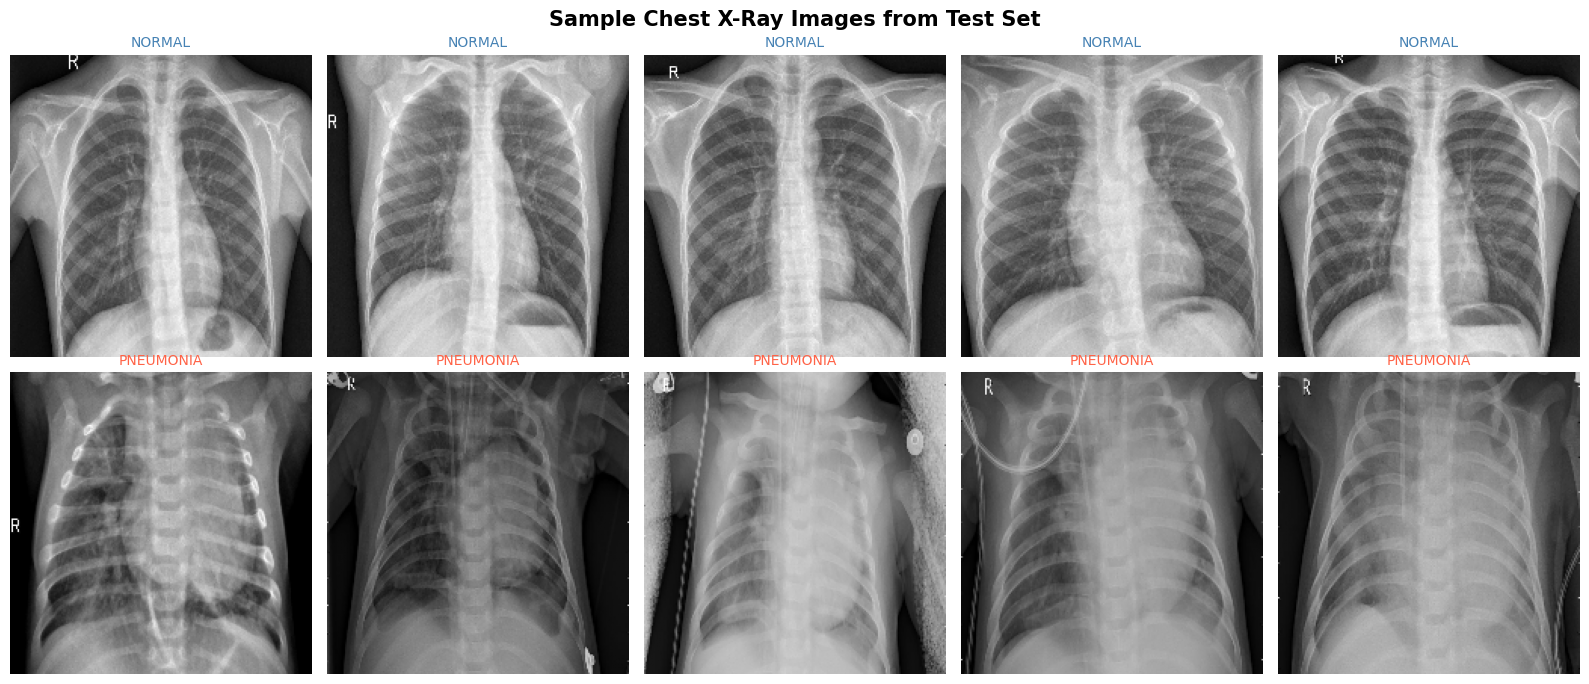

In [6]:
# === SAMPLE IMAGE GRID ===
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Sample Chest X-Ray Images from Test Set', fontsize=15, fontweight='bold')

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    folder = os.path.join(CHEST_TEST_DIR, cls_name)
    files = sorted(os.listdir(folder))[:5]
    for col, fname in enumerate(files):
        img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE_SVM, IMG_SIZE_SVM))
        axes[cls_idx][col].imshow(img, cmap='gray')
        axes[cls_idx][col].set_title(cls_name, fontsize=10,
                                      color='steelblue' if cls_idx==0 else 'tomato')
        axes[cls_idx][col].axis('off')

plt.tight_layout()
plt.show()

In [7]:
# === CNN DATA LOADER FOR EXPERIMENTS ===
def load_cnn_data_fraction(base_dir, classes, img_size=224, fraction=1.0, seed=42):
    """Load RGB images for CNN, applying a fraction to training data."""  
    np.random.seed(seed)
    X, y = [], []
    for cls, label in classes.items():
        folder = os.path.join(base_dir, cls)
        files = sorted(os.listdir(folder))
        n = max(1, int(len(files) * fraction))
        chosen = np.random.choice(files, n, replace=False)
        for fname in chosen:
            img = cv2.imread(os.path.join(folder, fname))
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
            X.append(img)
            y.append(label)
    X, y = np.array(X), np.array(y)
    # shuffle
    idx = np.random.permutation(len(y))
    return X[idx], y[idx]

# Load fixed test set for CNN (RGB)
print("Loading CNN test data (RGB, fixed) ...")
X_test_cnn, y_test_cnn = load_cnn_data_fraction(
    CHEST_TEST_DIR, CLASSES, img_size=IMG_SIZE_CNN, fraction=1.0, seed=SEED
)
print(f"  CNN test set: {X_test_cnn.shape}, labels: {np.bincount(y_test_cnn)}")

Loading CNN test data (RGB, fixed) ...
  CNN test set: (624, 224, 224, 3), labels: [234 390]


In [8]:
# Load validation set for CNN (from val/ folder, kept separate)
print("Loading CNN validation data from val/ ...")
X_val_cnn, y_val_cnn = load_cnn_data_fraction(
    CHEST_VAL_DIR, CLASSES, img_size=IMG_SIZE_CNN, fraction=1.0, seed=SEED
)
print(f"  Val  shape : {X_val_cnn.shape}, labels: {np.bincount(y_val_cnn)}")

# Full training data for CNN
print("\nLoading CNN training data (full) from train/ ...")
X_train_cnn, y_train_cnn = load_cnn_data_fraction(
    CHEST_TRAIN_DIR, CLASSES, img_size=IMG_SIZE_CNN, fraction=1.0, seed=SEED
)
print(f"  Train shape: {X_train_cnn.shape}, labels: {np.bincount(y_train_cnn)}")
print(f"  Test  shape: {X_test_cnn.shape},  labels: {np.bincount(y_test_cnn)}")

Loading CNN validation data from val/ ...
  Val  shape : (16, 224, 224, 3), labels: [8 8]

Loading CNN training data (full) from train/ ...
  Train shape: (5216, 224, 224, 3), labels: [1341 3875]
  Test  shape: (624, 224, 224, 3),  labels: [234 390]


In [9]:
# === DATA AUGMENTATION PIPELINE ===
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE = 16


train_datagen = ImageDataGenerator(  rotation_range=7,
                                     width_shift_range=0.05,
                                     height_shift_range=0.05,
                                     shear_range=0.2,
                                     zoom_range=0.45,
                                     horizontal_flip=True)
                                   
val_datagen = ImageDataGenerator(zoom_range=0.45)  


train_gen = train_datagen.flow(X_train_cnn, y_train_cnn, batch_size=BATCH_SIZE, seed=SEED)
val_gen   = val_datagen.flow(X_val_cnn,   y_val_cnn,   batch_size=BATCH_SIZE, seed=SEED)


In [10]:
# ==============================================================
# FULL DATASET SVM EXPERIMENTS
# ==============================================================

print("\n" + "="*70)
print("FULL DATASET SVM EXPERIMENTS")
print("="*70)


FULL DATASET SVM EXPERIMENTS



Training SVM with RBF kernel...

 SVM RBF TRAIN METRICS
  Accuracy    : 0.9933  (99.33%)
  F1-Score    : 0.9933
  Sensitivity : 0.9933
  Specificity : 0.9909

 SVM RBF TEST METRICS
  Accuracy    : 0.7708  (77.08%)
  F1-Score    : 0.7420
  Sensitivity : 0.7708
  Specificity : 0.6987


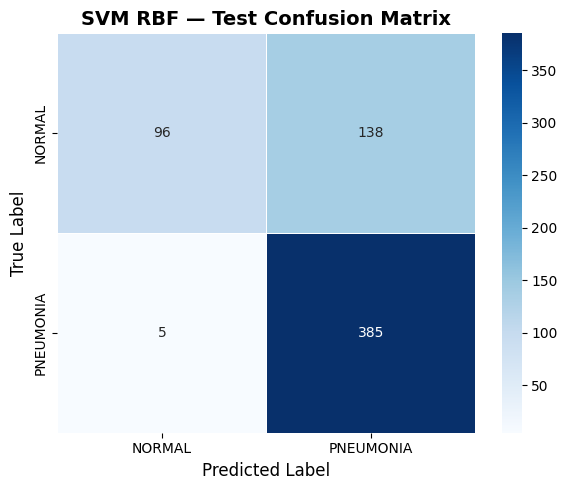

In [11]:
# --------------------------------------------------------------
# SVM RBF
# --------------------------------------------------------------

print("\nTraining SVM with RBF kernel...")

svm_rbf = SVC(kernel='rbf', random_state=SEED)
svm_rbf.fit(pca_train, y_train)
pred_rbf_train = svm_rbf.predict(pca_train)

pred_rbf_test = svm_rbf.predict(pca_test)
rbf_train_metrics = compute_metrics(y_train, pred_rbf_train)
rbf_test_metrics = compute_metrics(y_test, pred_rbf_test)

print_metrics("SVM RBF TRAIN", *rbf_train_metrics[:4])
print_metrics("SVM RBF TEST", *rbf_test_metrics[:4])

plot_confusion_matrix(rbf_test_metrics[4], CLASS_NAMES, title='SVM RBF — Test Confusion Matrix')


Training SVM with Linear kernel...

 SVM LINEAR TRAIN METRICS
  Accuracy    : 1.0000  (100.00%)
  F1-Score    : 1.0000
  Sensitivity : 1.0000
  Specificity : 1.0000

 SVM LINEAR TEST METRICS
  Accuracy    : 0.7548  (75.48%)
  F1-Score    : 0.7190
  Sensitivity : 0.7548
  Specificity : 0.6765


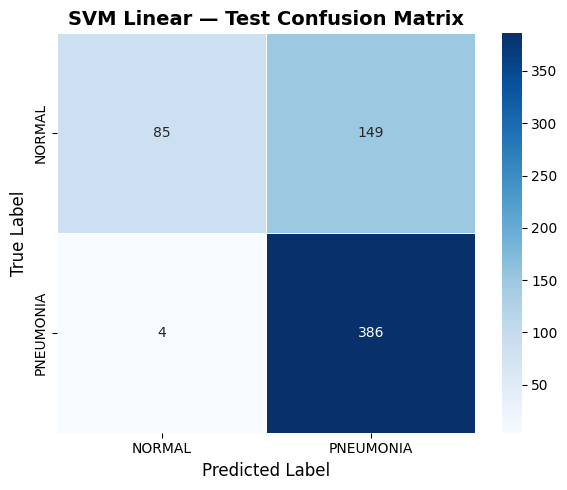

In [12]:
# --------------------------------------------------------------
# SVM LINEAR
# --------------------------------------------------------------

print("\nTraining SVM with Linear kernel...")

svm_linear = SVC(kernel='linear', random_state=SEED)
svm_linear.fit(pca_train, y_train)
pred_linear_train = svm_linear.predict(pca_train)
pred_linear_test = svm_linear.predict(pca_test)

linear_train_metrics = compute_metrics(y_train,pred_linear_train)
linear_test_metrics = compute_metrics(y_test,pred_linear_test)
print_metrics("SVM LINEAR TRAIN", *linear_train_metrics[:4])

print_metrics("SVM LINEAR TEST",*linear_test_metrics[:4])

plot_confusion_matrix(linear_test_metrics[4], CLASS_NAMES, title='SVM Linear — Test Confusion Matrix')

In [13]:
base_model = MobileNet(weights=None, include_top=False,input_shape=(IMG_SIZE_CNN, IMG_SIZE_CNN, 3)) 

x = base_model.output

# Add a global spatial average pooling layer
x = GlobalAveragePooling2D()(x)

# Add a logistic layer
predictions = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=predictions)
# Compile model
model.compile(optimizer='adam', loss = 'binary_crossentropy',
                           metrics = ['binary_accuracy', 'mae'])

I0000 00:00:1779044905.882158      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



FULL CNN TRAINING

Class weights:
{0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}

CNN model built successfully.

Callbacks configured.
Epoch 1/100


I0000 00:00:1779044922.473155      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - binary_accuracy: 0.7738 - loss: 0.4594 - mae: 0.2674
Epoch 1: val_loss improved from inf to 1.04689, saving model to best_pneumonia_cnn_model.keras
326/326 ━━━━━━━━━━━━━━━━━━━━ 94s 238ms/step - binary_accuracy: 0.7739 - loss: 0.4592 - mae: 0.2673 - val_binary_accuracy: 0.5000 - val_loss: 1.0469 - val_mae: 0.5000 - learning_rate: 0.0010
Epoch 2/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - binary_accuracy: 0.8496 - loss: 0.3485 - mae: 0.2049
Epoch 2: val_loss did not improve from 1.04689
326/326 ━━━━━━━━━━━━━━━━━━━━ 77s 235ms/step - binary_accuracy: 0.8496 - loss: 0.3484 - mae: 0.2049 - val_binary_accuracy: 0.5000 - val_loss: 2.6769 - val_mae: 0.4973 - learning_rate: 0.0010
Epoch 3/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - binary_accuracy: 0.8624 - loss: 0.3208 - mae: 0.1862
Epoch 3: val_loss improved from 1.04689 to 0.65231, saving model to best_pneumonia_cnn_model.keras
326/326 ━━━━━━━━━━━━━━━━━━━━ 77s 236ms/step - binary_accuracy

2026-05-17 20:12:38.183463: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



 CNN TEST METRICS
  Accuracy    : 0.9295  (92.95%)
  F1-Score    : 0.9293
  Sensitivity : 0.9295
  Specificity : 0.9222


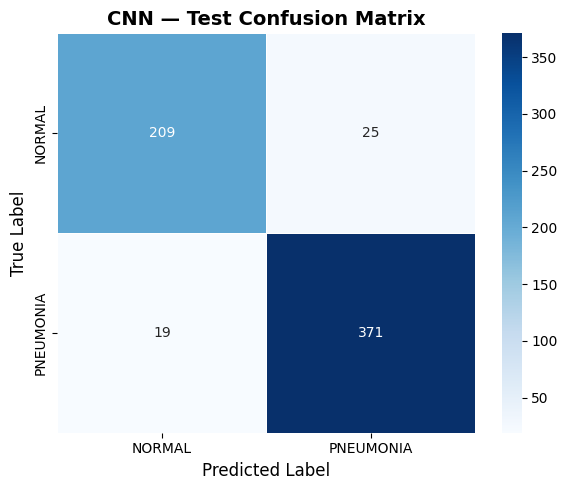

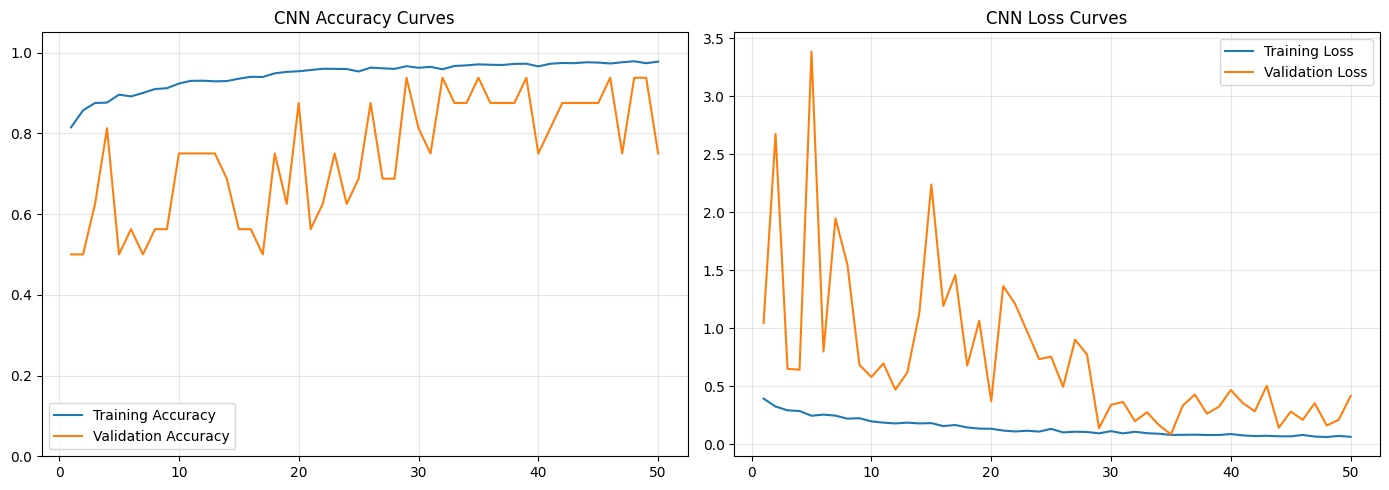

In [14]:
# ==============================================================
# FULL CNN PIPELINE
# ==============================================================

print("\n" + "="*70)
print("FULL CNN TRAINING")
print("="*70)

# --------------------------------------------------------------
# IMPORT
# --------------------------------------------------------------

from sklearn.utils.class_weight import (compute_class_weight)

# --------------------------------------------------------------
# CLASS WEIGHTS
# --------------------------------------------------------------

cw = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_cnn),
    y=y_train_cnn
)

class_weights_cnn = dict(enumerate(cw))
print("\nClass weights:")
print(class_weights_cnn)

# --------------------------------------------------------------
# RESET SESSION
# --------------------------------------------------------------

tf.keras.backend.clear_session()
gc.collect()
tf.random.set_seed(SEED)

# --------------------------------------------------------------
# BUILD CNN MODEL
# --------------------------------------------------------------

base_model = MobileNet(weights=None, include_top=False, input_shape=(IMG_SIZE_CNN, IMG_SIZE_CNN, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=predictions)

# --------------------------------------------------------------
# COMPILE MODEL
# --------------------------------------------------------------

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy', 'mae'])
print("\nCNN model built successfully.")
# --------------------------------------------------------------
# CALLBACKS
# --------------------------------------------------------------

BEST_CNN_PATH = ('best_pneumonia_cnn_model.keras')
callbacks_cnn = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),

    ModelCheckpoint(
        BEST_CNN_PATH,
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]
print("\nCallbacks configured.")

# --------------------------------------------------------------
# TRAIN MODEL
# --------------------------------------------------------------

history_cnn = model.fit(train_gen,
                        epochs=100,
                        validation_data=val_gen,
                        class_weight=class_weights_cnn,
                        callbacks=callbacks_cnn,
                        verbose=1
)

# --------------------------------------------------------------
# LOAD BEST MODEL
# --------------------------------------------------------------

print("\nLoading BEST CNN model...")

best_cnn_model = load_model(BEST_CNN_PATH)

# --------------------------------------------------------------
# TEST EVALUATION
# --------------------------------------------------------------

yprob_cnn = best_cnn_model.predict(X_test_cnn,
                                   verbose=0
)

ypred_cnn = (yprob_cnn > 0.5).astype(int).flatten()
cnn_test_metrics = compute_metrics(y_test_cnn, ypred_cnn)
print_metrics("CNN TEST", *cnn_test_metrics[:4])
plot_confusion_matrix(cnn_test_metrics[4], CLASS_NAMES, title='CNN — Test Confusion Matrix')
# --------------------------------------------------------------
# TRAINING CURVES
# --------------------------------------------------------------

acc = history_cnn.history['binary_accuracy']
val_acc = history_cnn.history['val_binary_accuracy']
loss = history_cnn.history['loss']
val_loss = history_cnn.history['val_loss']
epochs_range = range(1, len(acc) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14,5))
# --------------------------------------------------------------
# ACCURACY CURVES
# --------------------------------------------------------------

axes[0].plot(epochs_range, acc, label='Training Accuracy')
axes[0].plot(epochs_range, val_acc, label='Validation Accuracy')
axes[0].set_title('CNN Accuracy Curves')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1.05)
# --------------------------------------------------------------
# LOSS CURVES
# --------------------------------------------------------------

axes[1].plot(epochs_range, loss, label='Training Loss')
axes[1].plot(epochs_range, val_loss, label='Validation Loss')
axes[1].set_title('CNN Loss Curves')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# ==============================================================
# PERCENTAGE EXPERIMENTS
# ==============================================================

fractions = [0.2, 0.4, 0.6, 0.8]
percentages = [20, 40, 60, 80]
rbf_results = {'acc': [], 'f1': [], 'sens': [], 'spec': []}
linear_results = {'acc': [], 'f1': [], 'sens': [], 'spec': []}
cnn_results = {'acc': [],'f1': [], 'sens': [], 'spec': []}

print("\n" + "="*70)
print("TRAINING DATA PERCENTAGE EXPERIMENTS")
print("="*70)

for frac, pct in zip(fractions, percentages):
    print("\n" + "="*60)
    print(f"TRAINING WITH {pct}% DATA")
    print("="*60)
    # ----------------------------------------------------------
    # RESET EVERYTHING
    # ----------------------------------------------------------
    tf.keras.backend.clear_session()
    gc.collect()
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    random.seed(SEED)

    # ----------------------------------------------------------
    # SAMPLE TRAINING INDICES ONCE
    # ----------------------------------------------------------

    n_samples = int(len(y_train) * frac)
    idx = np.random.choice(len(y_train), n_samples, replace=False)

    # ----------------------------------------------------------
    # SVM SUBSET
    # ----------------------------------------------------------

    X_sub_flat = X_train_flat[idx]
    y_sub = y_train[idx]

    # ----------------------------------------------------------
    # PCA
    # ----------------------------------------------------------

    pca_exp = PCA(n_components=0.98,random_state=SEED)
    X_sub_pca = pca_exp.fit_transform(X_sub_flat)
    X_test_pca = pca_exp.transform(X_test_flat)

    # ----------------------------------------------------------
    # RBF SVM
    # ----------------------------------------------------------

    svm_rbf_exp = SVC(kernel='rbf',random_state=SEED)
    svm_rbf_exp.fit(X_sub_pca,y_sub)
    pred_rbf = svm_rbf_exp.predict(X_test_pca)
    acc, f1, sens, spec, _ = compute_metrics(y_test,pred_rbf)
    rbf_results['acc'].append(acc)
    rbf_results['f1'].append(f1)
    rbf_results['sens'].append(sens)
    rbf_results['spec'].append(spec)

    # ----------------------------------------------------------
    # LINEAR SVM
    # ----------------------------------------------------------

    svm_linear_exp = SVC(kernel='linear', random_state=SEED)
    svm_linear_exp.fit(X_sub_pca, y_sub)
    pred_linear = svm_linear_exp.predict(X_test_pca)
    acc, f1, sens, spec, _ = compute_metrics(y_test, pred_linear)
    linear_results['acc'].append(acc)
    linear_results['f1'].append(f1)
    linear_results['sens'].append(sens)
    linear_results['spec'].append(spec)
    # ----------------------------------------------------------
    # CNN SUBSET
    # ----------------------------------------------------------

    X_sub_cnn = X_train_cnn[idx]
    y_sub_cnn = y_train_cnn[idx]

    # ----------------------------------------------------------
    # GENERATORS
    # ----------------------------------------------------------
    train_gen_exp = train_datagen.flow(X_sub_cnn, y_sub_cnn, batch_size=BATCH_SIZE, seed=SEED)
    val_gen_exp = val_datagen.flow(X_val_cnn, y_val_cnn, batch_size=BATCH_SIZE, seed=SEED)

    # ----------------------------------------------------------
    # CLASS WEIGHTS
    # ----------------------------------------------------------

    cw = compute_class_weight(class_weight='balanced', classes=np.unique(y_sub_cnn), y=y_sub_cnn)
    class_weights_exp = dict(enumerate(cw))

    # ----------------------------------------------------------
    # BUILD FRESH CNN
    # ----------------------------------------------------------

    base_model = MobileNet(weights=None, include_top=False, input_shape=( IMG_SIZE_CNN, IMG_SIZE_CNN, 3))
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    pred = Dense(1, activation='sigmoid')(x)
    cnn_exp = Model(inputs=base_model.input, outputs=pred)
    cnn_exp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])

    # ----------------------------------------------------------
    # CALLBACKS
    # ----------------------------------------------------------

    model_path = (f'cnn_{pct}_percent.keras')
    callbacks_exp = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
        ModelCheckpoint(model_path, monitor='val_loss', save_best_only=True, mode='min', verbose=0)
    ]

    # ----------------------------------------------------------
    # TRAIN CNN
    # ----------------------------------------------------------

    cnn_exp.fit(train_gen_exp, epochs=80,
                validation_data=val_gen_exp,
                class_weight=class_weights_exp,
                callbacks=callbacks_exp,
                verbose=2
    )

    # ----------------------------------------------------------
    # LOAD BEST CNN
    # ----------------------------------------------------------

    best_exp_model = load_model(model_path)
    yprob = best_exp_model.predict(X_test_cnn,
                               verbose=1
    )

    ypred = (yprob > 0.5).astype(int).flatten()
    acc, f1, sens, spec, _ = compute_metrics(y_test_cnn,ypred)
    cnn_results['acc'].append(acc)
    cnn_results['f1'].append(f1)
    cnn_results['sens'].append(sens)
    cnn_results['spec'].append(spec)

    # ----------------------------------------------------------
    # CLEAN MEMORY
    # ----------------------------------------------------------
    
    del cnn_exp
    del best_exp_model
    del train_gen_exp
    del val_gen_exp
    del base_model
    
    gc.collect()
    
    tf.keras.backend.clear_session()

    
    print(
        f"{pct}% → "
        f"RBF={rbf_results['acc'][-1]:.4f} | "
        f"Linear={linear_results['acc'][-1]:.4f} | "
        f"CNN={cnn_results['acc'][-1]:.4f}"
    )


TRAINING DATA PERCENTAGE EXPERIMENTS

TRAINING WITH 20% DATA
Epoch 1/80
66/66 - 29s - 445ms/step - binary_accuracy: 0.7565 - loss: 0.5322 - val_binary_accuracy: 0.5000 - val_loss: 1.2955
Epoch 2/80
66/66 - 15s - 231ms/step - binary_accuracy: 0.8389 - loss: 0.3642 - val_binary_accuracy: 0.5000 - val_loss: 2.4136
Epoch 3/80
66/66 - 15s - 229ms/step - binary_accuracy: 0.8514 - loss: 0.3369 - val_binary_accuracy: 0.5000 - val_loss: 3.0772
Epoch 4/80
66/66 - 15s - 229ms/step - binary_accuracy: 0.8648 - loss: 0.3487 - val_binary_accuracy: 0.5000 - val_loss: 2.5908
Epoch 5/80
66/66 - 15s - 230ms/step - binary_accuracy: 0.8773 - loss: 0.2995 - val_binary_accuracy: 0.5000 - val_loss: 2.6951
Epoch 6/80
66/66 - 15s - 227ms/step - binary_accuracy: 0.8744 - loss: 0.2944 - val_binary_accuracy: 0.5000 - val_loss: 2.9409
Epoch 7/80
66/66 - 15s - 228ms/step - binary_accuracy: 0.8466 - loss: 0.3430 - val_binary_accuracy: 0.5000 - val_loss: 2.5316
Epoch 8/80
66/66 - 15s - 229ms/step - binary_accuracy: 0

2026-05-17 20:15:57.944906: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step
20% → RBF=0.7724 | Linear=0.7596 | CNN=0.6250

TRAINING WITH 40% DATA
Epoch 1/80
131/131 - 47s - 360ms/step - binary_accuracy: 0.8178 - loss: 0.4334 - val_binary_accuracy: 0.5000 - val_loss: 0.9559
Epoch 2/80
131/131 - 32s - 242ms/step - binary_accuracy: 0.8485 - loss: 0.3468 - val_binary_accuracy: 0.5000 - val_loss: 1.0803
Epoch 3/80
131/131 - 31s - 240ms/step - binary_accuracy: 0.8701 - loss: 0.3035 - val_binary_accuracy: 0.5000 - val_loss: 0.8971
Epoch 4/80
131/131 - 31s - 238ms/step - binary_accuracy: 0.8797 - loss: 0.2697 - val_binary_accuracy: 0.5000 - val_loss: 2.9584
Epoch 5/80
131/131 - 32s - 241ms/step - binary_accuracy: 0.8854 - loss: 0.2760 - val_binary_accuracy: 0.5000 - val_loss: 3.3721
Epoch 6/80
131/131 - 32s - 242ms/step - binary_accuracy: 0.8955 - loss: 0.2480 - val_binary_accuracy: 0.5625 - val_loss: 3.4869
Epoch 7/80
131/131 - 32s - 244ms/step - binary_accuracy: 0.8907 - loss: 0.2702 - val_binary_accuracy: 0.7500 - val_loss: 0

2026-05-17 20:42:35.052946: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step
40% → RBF=0.7724 | Linear=0.7628 | CNN=0.8125

TRAINING WITH 60% DATA
Epoch 1/80
196/196 - 58s - 295ms/step - binary_accuracy: 0.8303 - loss: 0.3983 - val_binary_accuracy: 0.5000 - val_loss: 2.1441
Epoch 2/80
196/196 - 44s - 224ms/step - binary_accuracy: 0.8623 - loss: 0.3261 - val_binary_accuracy: 0.5000 - val_loss: 3.1805
Epoch 3/80
196/196 - 44s - 223ms/step - binary_accuracy: 0.8696 - loss: 0.3074 - val_binary_accuracy: 0.5000 - val_loss: 2.6349
Epoch 4/80
196/196 - 44s - 224ms/step - binary_accuracy: 0.8776 - loss: 0.2761 - val_binary_accuracy: 0.7500 - val_loss: 0.5725
Epoch 5/80
196/196 - 44s - 223ms/step - binary_accuracy: 0.8929 - loss: 0.2606 - val_binary_accuracy: 0.6250 - val_loss: 0.9378
Epoch 6/80
196/196 - 44s - 225ms/step - binary_accuracy: 0.8920 - loss: 0.2578 - val_binary_accuracy: 0.8125 - val_loss: 0.3966
Epoch 7/80
196/196 - 44s - 226ms/step - binary_accuracy: 0.8996 - loss: 0.2381 - val_binary_accuracy: 0.8125 - val_loss: 0

2026-05-17 20:56:24.664246: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step
60% → RBF=0.7596 | Linear=0.7436 | CNN=0.6955

TRAINING WITH 80% DATA
Epoch 1/80
261/261 - 73s - 278ms/step - binary_accuracy: 0.8265 - loss: 0.3967 - val_binary_accuracy: 0.5000 - val_loss: 1.7715
Epoch 2/80
261/261 - 59s - 225ms/step - binary_accuracy: 0.8773 - loss: 0.2844 - val_binary_accuracy: 0.5000 - val_loss: 3.6863
Epoch 3/80
261/261 - 59s - 226ms/step - binary_accuracy: 0.8782 - loss: 0.2872 - val_binary_accuracy: 0.6250 - val_loss: 2.1074
Epoch 4/80
261/261 - 59s - 225ms/step - binary_accuracy: 0.8893 - loss: 0.2611 - val_binary_accuracy: 0.6250 - val_loss: 1.8346
Epoch 5/80
261/261 - 59s - 226ms/step - binary_accuracy: 0.8936 - loss: 0.2555 - val_binary_accuracy: 0.5000 - val_loss: 0.9151
Epoch 6/80
261/261 - 59s - 226ms/step - binary_accuracy: 0.9036 - loss: 0.2286 - val_binary_accuracy: 0.8125 - val_loss: 0.6886
Epoch 7/80
261/261 - 59s - 226ms/step - binary_accuracy: 0.8933 - loss: 0.2552 - val_binary_accuracy: 0.8125 - val_loss: 0

2026-05-17 21:15:04.093352: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step
80% → RBF=0.7628 | Linear=0.7500 | CNN=0.8333


In [16]:
# ==============================================================
# RESULTS TABLE
# ==============================================================

exp_df = pd.DataFrame({
    'Percentage (%)': percentages,
    'RBF Accuracy': rbf_results['acc'],
    'Linear Accuracy': linear_results['acc'],
    'CNN Accuracy': cnn_results['acc'],
    'RBF F1': rbf_results['f1'],
    'Linear F1': linear_results['f1'],
    'CNN F1': cnn_results['f1'],
    'RBF Sensitivity': rbf_results['sens'],
    'Linear Sensitivity': linear_results['sens'],
    'CNN Sensitivity': cnn_results['sens'],
    'RBF Specificity': rbf_results['spec'],
    'Linear Specificity': linear_results['spec'],
    'CNN Specificity': cnn_results['spec']
})

exp_df = exp_df.set_index(
    'Percentage (%)'
)

display(
    exp_df.style
    .format("{:.4f}")
    .set_caption(
        "Training Data Percentage Experiments"
    )
)

,RBF Accuracy,Linear Accuracy,CNN Accuracy,RBF F1,Linear F1,CNN F1,RBF Sensitivity,Linear Sensitivity,CNN Sensitivity,RBF Specificity,Linear Specificity,CNN Specificity
Percentage (%),,,,,,,,,,,,
20,0.7724,0.7596,0.6250,0.7456,0.7266,0.4808,0.7724,0.7596,0.6250,0.7026,0.6838,0.5000
40,0.7724,0.7628,0.8125,0.7442,0.7311,0.8155,0.7724,0.7628,0.8125,0.7009,0.6880,0.8355
60,0.7596,0.7436,0.6955,0.7274,0.7047,0.6934,0.7596,0.7436,0.6955,0.6846,0.6632,0.7487
80,0.7628,0.7500,0.8333,0.7318,0.7130,0.8359,0.7628,0.7500,0.8333,0.6889,0.6709,0.8513


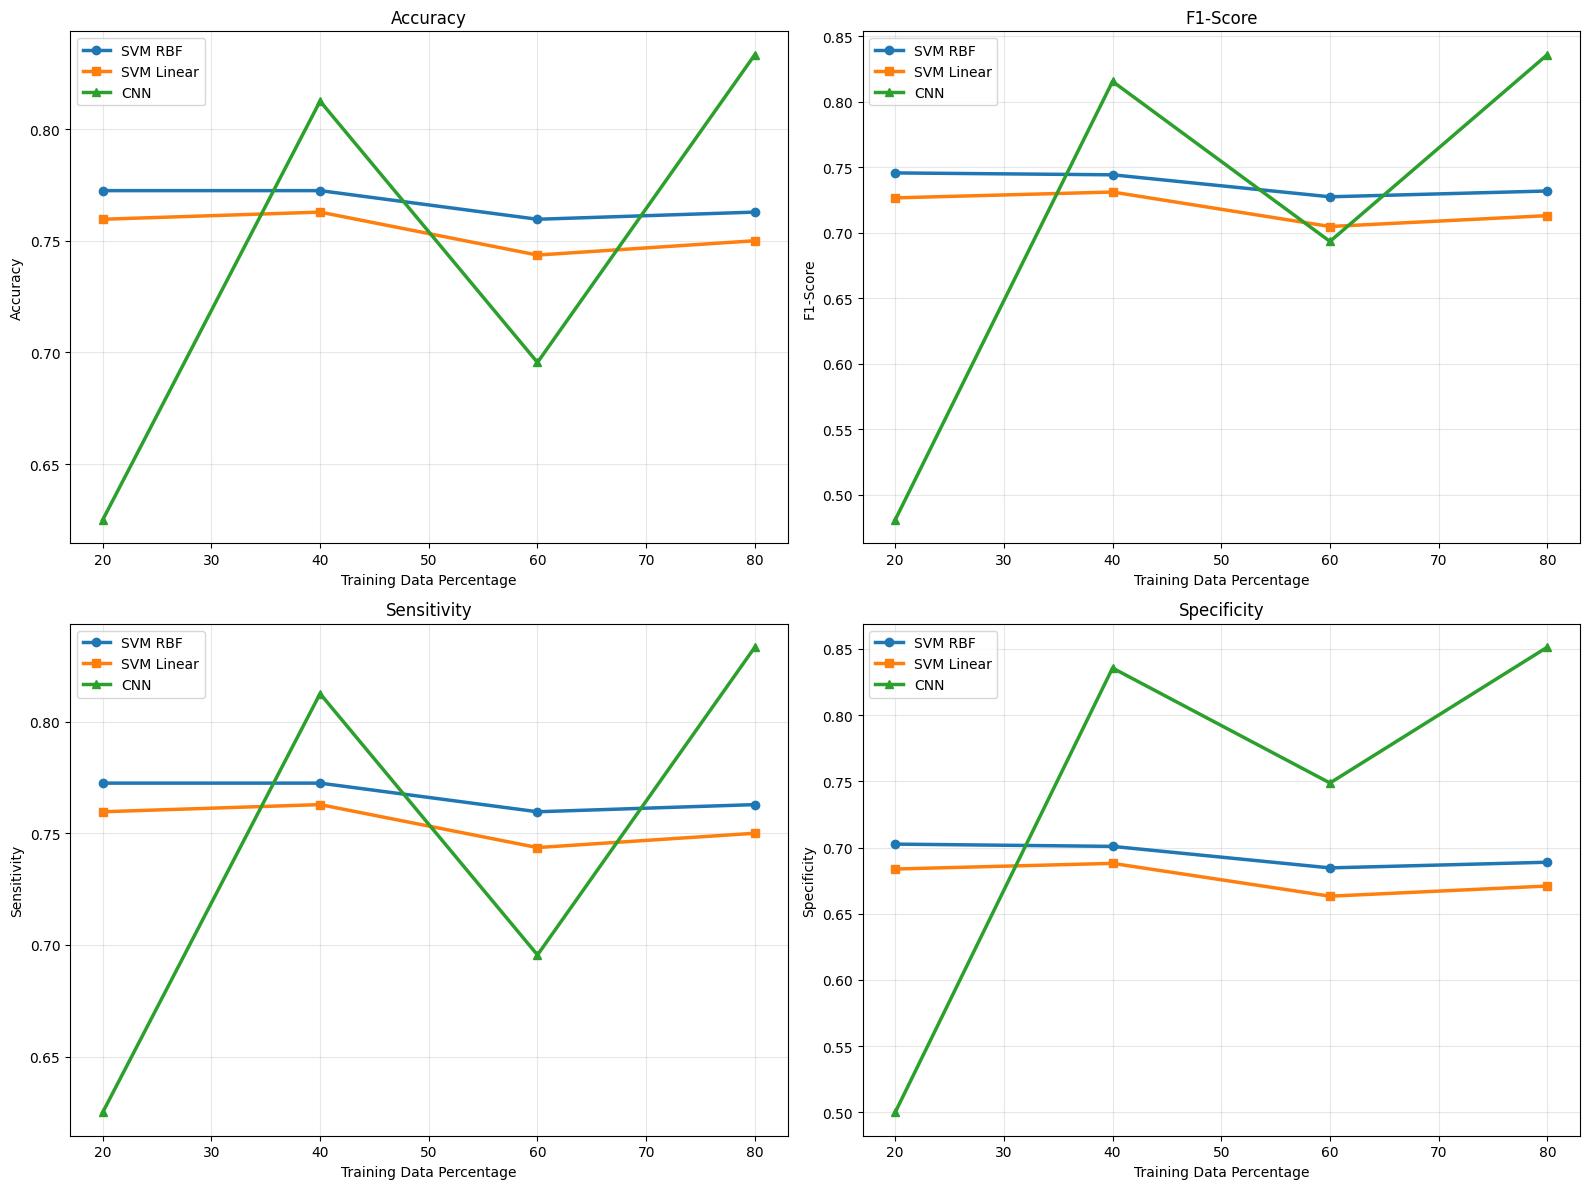

In [17]:
# ==============================================================
# COMPARISON PLOTS
# ==============================================================

metric_keys = ['acc', 'f1', 'sens', 'spec']
metric_names = ['Accuracy', 'F1-Score', 'Sensitivity', 'Specificity']

fig, axes = plt.subplots(2, 2, figsize=(16,12))
axes = axes.flatten()

for ax, key, metric_name in zip(
    axes,
    metric_keys,
    metric_names
):

    ax.plot(percentages, rbf_results[key], marker='o', linewidth=2.5, label='SVM RBF')
    ax.plot(percentages, linear_results[key], marker='s', linewidth=2.5, label='SVM Linear')
    ax.plot(percentages, cnn_results[key], marker='^', linewidth=2.5, label='CNN')

    ax.set_title(metric_name)
    ax.set_xlabel('Training Data Percentage')
    ax.set_ylabel(metric_name)
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()